# 03 · LSTM with Attention — Sequence Model

The Isolation Forest saw a trace as a bag of counts. This model reads it
**in order**, which is what actually distinguishes an attack.

```
syscall numbers
      |
  Embedding(351 -> 64)       each syscall becomes a learned 64-d vector
      |
  LSTM(64 -> 128, 2 layers)  carries state across the sequence
      |
  Attention(128 -> 1)        weights the timesteps that matter
      |
  Linear(128 -> 64 -> 1)     normal / attack
```

**Why attention?** A 200-step trace has maybe 10 steps that matter. A plain LSTM
must squeeze everything into its final hidden state, and early evidence fades.
Attention scores every timestep and takes a weighted sum, so a suspicious burst
at step 12 survives to the classifier.

Training takes about 2–4 minutes on the RTX 3050 and uses ~150 MB of VRAM.

In [13]:
# ── Project paths (edit ADFA_ROOT if your dataset lives elsewhere) ────────────
import os, sys, glob, json, warnings
warnings.filterwarnings("ignore")

PROJECT   = "/home/sudipto-roy-s-hawon/Downloads/Project"
ADFA_ROOT = "/home/sudipto-roy-s-hawon/Downloads/ADFA-LD"
MODEL_DIR = os.path.join(PROJECT, "ml", "saved_model")
os.makedirs(MODEL_DIR, exist_ok=True)

# make `import live_predictor` work from inside ml/
sys.path.insert(0, os.path.join(PROJECT, "ml"))

assert os.path.isdir(ADFA_ROOT), f"ADFA-LD not found at {ADFA_ROOT}"
print("Project  :", PROJECT)
print("Dataset  :", ADFA_ROOT)
print("Models   :", MODEL_DIR)

Project  : /home/sudipto-roy-s-hawon/Downloads/Project
Dataset  : /home/sudipto-roy-s-hawon/Downloads/ADFA-LD
Models   : /home/sudipto-roy-s-hawon/Downloads/Project/ml/saved_model


## 1 · Hyperparameters & device

In [14]:
import torch, torch.nn as nn
import numpy as np

SEQ_LEN     = 200    # every trace padded/truncated to this length
MAX_SYSCALL = 351    # syscall ids 0..350
PAD_TOKEN   = 350    # reserved id used for padding
EMBED_DIM   = 64
HIDDEN_DIM  = 128
NUM_LAYERS  = 2
BATCH_SIZE  = 128
EPOCHS      = 30
LR          = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU   :", torch.cuda.get_device_name(0))
    print(f"VRAM  : {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB free")

device: cuda
GPU   : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM  : 4.8 GB free


## 2 · Load and pad

The LSTM needs a rectangular batch, so every trace becomes exactly `SEQ_LEN`
steps: truncate if longer, pad with `PAD_TOKEN` if shorter. The embedding is
told `padding_idx=PAD_TOKEN`, so padding contributes a fixed zero vector and
never receives gradient.

In [15]:
def read_trace(p):
    with open(p) as f:
        return [int(x) for x in f.read().split() if x.isdigit()]

def fit_length(seq, n=SEQ_LEN):
    return seq[:n] if len(seq) >= n else seq + [PAD_TOKEN] * (n - len(seq))

X, y = [], []
for pattern, label in [("Training_Data_Master/*.txt",   0),
                       ("Validation_Data_Master/*.txt", 0),
                       ("Attack_Data_Master/*/*.txt",   1)]:
    for f in glob.glob(f"{ADFA_ROOT}/{pattern}"):
        t = read_trace(f)
        if len(t) > 20:
            X.append(fit_length(t)); y.append(label)

X = np.array(X, dtype=np.int64)
y = np.array(y, dtype=np.float32)
n0, n1 = int((y == 0).sum()), int((y == 1).sum())
print(f"normal {n0}   attack {n1}   ratio {n0/n1:.1f} : 1")
print(f"X {X.shape}")

normal 5205   attack 746   ratio 7.0 : 1
X (5951, 200)


## 3 · Train / validation split

In [16]:
rng = np.random.default_rng(42)
idx = rng.permutation(len(X))
cut = int(0.8 * len(idx))
tr, va = idx[:cut], idx[cut:]

X_tr, y_tr = X[tr], y[tr]
X_va, y_va = X[va], y[va]
print(f"train {len(X_tr)}   val {len(X_va)}")
print(f"val attack share: {100*y_va.mean():.1f}%")

train 4760   val 1191
val attack share: 12.6%


## 4 · Dataloaders with a balanced sampler

Normal traces outnumber attacks ~7:1. Left alone the model can score ~87 % by
predicting "normal" every time — accurate and useless.

`WeightedRandomSampler` draws each class with probability ∝ 1/frequency, so a
batch is roughly balanced. We also pass `pos_weight` to the loss as a second
correction. Together they make a missed attack expensive.

`num_workers=0` is deliberate — Python 3.14's forkserver crashes the CUDA
context in worker processes on this setup.

In [17]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

class TraceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):      return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

w = np.where(y_tr == 0, 1.0 / (y_tr == 0).sum(), 1.0 / (y_tr == 1).sum())
sampler = WeightedRandomSampler(torch.tensor(w, dtype=torch.double),
                                num_samples=len(w), replacement=True)

train_loader = DataLoader(TraceDataset(X_tr, y_tr), batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(TraceDataset(X_va, y_va), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

xb, yb = next(iter(train_loader))
print(f"batch {tuple(xb.shape)}   attack share in batch: {yb.mean():.2f}  (~0.50 = balanced)")

batch (128, 200)   attack share in batch: 0.48  (~0.50 = balanced)


## 5 · Model

In [18]:
class SyscallLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(MAX_SYSCALL + 1, EMBED_DIM, padding_idx=PAD_TOKEN)
        self.lstm  = nn.LSTM(EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                             batch_first=True, dropout=0.3)
        self.attn  = nn.Linear(HIDDEN_DIM, 1)
        self.classifier  = nn.Sequential(
            nn.Linear(HIDDEN_DIM, 64), nn.ReLU(),
            nn.Dropout(0.4), nn.Linear(64, 1),
        )

    def forward(self, x, return_attn=False):
        e      = self.embed(x)                        # (B, L, E)
        out, _ = self.lstm(e)                         # (B, L, H)
        w      = torch.softmax(self.attn(out), dim=1) # (B, L, 1) weights sum to 1
        ctx    = (w * out).sum(dim=1)                 # (B, H) weighted summary
        logit  = self.classifier(ctx).squeeze(-1)           # (B,) raw score
        return (logit, w.squeeze(-1)) if return_attn else logit

model = SyscallLSTM().to(DEVICE)
nparam = sum(p.numel() for p in model.parameters())
print(f"parameters: {nparam:,}  (~{nparam*4/1024**2:.1f} MB fp32)")
if DEVICE.type == "cuda":
    print(f"VRAM after load: {torch.cuda.memory_allocated()/1024**2:.1f} MB")

parameters: 262,402  (~1.0 MB fp32)
VRAM after load: 23.0 MB


## 6 · Loss, optimiser, schedule

- `BCEWithLogitsLoss` — sigmoid and cross-entropy fused, numerically stable
- `pos_weight` — a missed attack costs ~7× a false alarm
- `CosineAnnealingLR` — decays 1e-3 → 1e-5 so late epochs settle instead of bouncing
- gradient clipping at 1.0 — standard guard against exploding gradients in RNNs

In [19]:
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([n0/n1], device=DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
print(f"pos_weight = {n0/n1:.2f}")

pos_weight = 6.98


## 7 · Train

We track **AUC**, not accuracy — AUC is threshold-free and does not flatter a
model that just predicts the majority class. The best checkpoint by validation
AUC is kept in memory.

In [20]:
from sklearn.metrics import roc_auc_score

best_auc, best_state, history = 0.0, None, []

for epoch in range(1, EPOCHS + 1):
    model.train()
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    scheduler.step()

    model.eval()
    probs, labels, vlosses = [], [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logit = model(xb)
            vlosses.append(criterion(logit, yb).item())
            probs.extend(torch.sigmoid(logit).cpu().numpy())
            labels.extend(yb.cpu().numpy())

    probs, labels = np.array(probs), np.array(labels)
    auc = roc_auc_score(labels, probs)
    acc = ((probs >= 0.5).astype(int) == labels).mean()
    history.append((np.mean(losses), np.mean(vlosses), acc, auc))

    star = ""
    if auc > best_auc:
        best_auc  = auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        star = "  *best*"
    if epoch % 5 == 0 or epoch == 1 or star:
        print(f"epoch {epoch:>3} | train {np.mean(losses):.4f} | "
              f"val {np.mean(vlosses):.4f} | acc {acc:>6.1%} | AUC {auc:.4f}{star}")

print(f"\nbest validation AUC: {best_auc:.4f}")

epoch   1 | train 1.5937 | val 1.1915 | acc  47.3% | AUC 0.8778  *best*
epoch   2 | train 0.8991 | val 0.7689 | acc  74.8% | AUC 0.9270  *best*
epoch   3 | train 0.6411 | val 0.5554 | acc  85.7% | AUC 0.9494  *best*
epoch   4 | train 0.5218 | val 0.5967 | acc  85.0% | AUC 0.9614  *best*
epoch   5 | train 0.5263 | val 0.5300 | acc  85.7% | AUC 0.9689  *best*
epoch   6 | train 0.4615 | val 0.5275 | acc  86.0% | AUC 0.9712  *best*
epoch   7 | train 0.3846 | val 0.4442 | acc  86.2% | AUC 0.9765  *best*
epoch   8 | train 0.3660 | val 0.3566 | acc  89.8% | AUC 0.9790  *best*
epoch   9 | train 0.3343 | val 0.4181 | acc  87.8% | AUC 0.9806  *best*
epoch  10 | train 0.3415 | val 0.3825 | acc  89.3% | AUC 0.9791
epoch  11 | train 0.2860 | val 0.3590 | acc  89.8% | AUC 0.9809  *best*
epoch  12 | train 0.2962 | val 0.3363 | acc  91.3% | AUC 0.9822  *best*
epoch  13 | train 0.2899 | val 0.3056 | acc  91.8% | AUC 0.9823  *best*
epoch  14 | train 0.2524 | val 0.3162 | acc  92.4% | AUC 0.9829  *best*


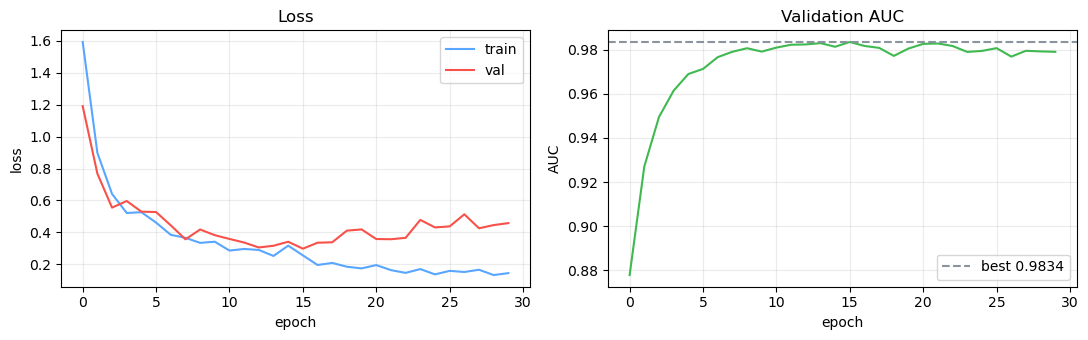

In [21]:
import matplotlib.pyplot as plt
h = np.array(history)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.5))
a1.plot(h[:,0], label="train", color="#58a6ff")
a1.plot(h[:,1], label="val",   color="#f85149")
a1.set_xlabel("epoch"); a1.set_ylabel("loss"); a1.set_title("Loss")
a1.legend(); a1.grid(alpha=.25)
a2.plot(h[:,3], color="#3fb950")
a2.axhline(best_auc, ls="--", c="#8b949e", label=f"best {best_auc:.4f}")
a2.set_xlabel("epoch"); a2.set_ylabel("AUC"); a2.set_title("Validation AUC")
a2.legend(); a2.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 8 · Final evaluation

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

model.load_state_dict(best_state); model.eval()
probs, labels = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        probs.extend(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
        labels.extend(yb.numpy())
probs, labels = np.array(probs), np.array(labels)
pred = (probs >= 0.5).astype(int)

print(classification_report(labels, pred, target_names=["Normal", "Attack"]))
tn, fp, fn, tp = confusion_matrix(labels, pred).ravel()
print(f"                 predicted")
print(f"               normal  attack")
print(f"  actual normal {tn:>6}  {fp:>6}   <- {fp} false alarms")
print(f"  actual attack {fn:>6}  {tp:>6}   <- {fn} missed")

              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96      1041
      Attack       0.68      0.98      0.80       150

    accuracy                           0.94      1191
   macro avg       0.84      0.96      0.88      1191
weighted avg       0.96      0.94      0.94      1191

                 predicted
               normal  attack
  actual normal    971      70   <- 70 false alarms
  actual attack      3     147   <- 3 missed


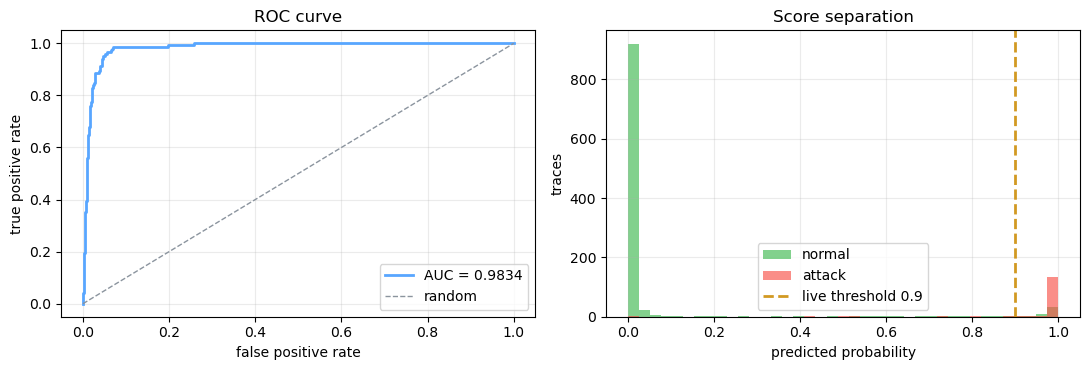

In [23]:
fpr, tpr, _ = roc_curve(labels, probs)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(fpr, tpr, color="#58a6ff", lw=2, label=f"AUC = {best_auc:.4f}")
a1.plot([0,1], [0,1], ls="--", c="#8b949e", lw=1, label="random")
a1.set_xlabel("false positive rate"); a1.set_ylabel("true positive rate")
a1.set_title("ROC curve"); a1.legend(); a1.grid(alpha=.25)

bins = np.linspace(0, 1, 40)
a2.hist(probs[labels==0], bins=bins, alpha=.65, label="normal", color="#3fb950")
a2.hist(probs[labels==1], bins=bins, alpha=.65, label="attack", color="#f85149")
a2.axvline(0.9, color="#d29922", ls="--", lw=2, label="live threshold 0.9")
a2.set_xlabel("predicted probability"); a2.set_ylabel("traces")
a2.set_title("Score separation"); a2.legend(); a2.grid(alpha=.25)
plt.tight_layout(); plt.show()

### Why the live threshold is 0.9, not 0.5

The right histogram shows why. On clean held-out data 0.5 separates the classes
well, but live traffic is messier than ADFA-LD — modern glibc, `openat`
everywhere, systemd. Normal processes drift upward and cross 0.5 more often
than the validation set suggests.

Notebook 04 measures this directly and shows 0.9 keeps detection while cutting
false alarms.

## 9 · Save

In [ ]:
torch.save(best_state, f"{MODEL_DIR}/lstm_model.pt")

json.dump({
    "seq_len": SEQ_LEN, "max_syscall": MAX_SYSCALL, "pad_token": PAD_TOKEN,
    "embed_dim": EMBED_DIM, "hidden_dim": HIDDEN_DIM, "num_layers": NUM_LAYERS,
    "threshold": 0.9,                 # tuned for live use in notebook 04
    "min_display_syscalls": 50,
    "best_auc": round(float(best_auc), 4),
    "note": "threshold 0.9 (not 0.5): fewer false positives on live traffic",
}, open(f"{MODEL_DIR}/lstm_config.json", "w"), indent=2)

print(f"lstm_model.pt     {os.path.getsize(f'{MODEL_DIR}/lstm_model.pt'):>9,} bytes")
print(f"lstm_config.json  {os.path.getsize(f'{MODEL_DIR}/lstm_config.json'):>9,} bytes")
print(f"\nbest AUC {best_auc:.4f} -> loaded live by src/dashboard.py")

lstm_model.pt     1,055,157 bytes
lstm_config.json        269 bytes

best AUC 0.9834 -> loaded live by src/dashboard.py


: 

---
| | Isolation Forest | LSTM + Attention |
|---|---|---|
| Supervision | none | labelled |
| Reads order | barely | yes |
| Parameters | 200 trees | ~262 K |
| Hardware | CPU, seconds | GPU, minutes |
| Validation AUC | — | **~0.985** |

**Next:** `04_live_inference.ipynb` — feed it real x86-64 syscalls and tune the
threshold that `dashboard.py` actually uses.